#Installing Required Libraries


In [ ]:
!pip install -q librosa soundfile scikit-learn pandas numpy matplotlib joblib

# Importing Libraries

In [8]:
import os
import zipfile
import warnings
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.") #To Confirm that the process is sucessfull or not

Libraries imported successfully.


# Importing Dataset

In [9]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


# Extracting Dataset

# Mapping the Emotions

In [19]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/ravdess"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [20]:
print(os.listdir("/content/ravdess"))

['Actor_11', 'Actor_20', 'Actor_14', 'Actor_23', 'Actor_15', 'Actor_04', 'Actor_12', 'Actor_05', 'Actor_21', 'Actor_10', 'audio_speech_actors_01-24', 'Actor_03', 'Actor_07', 'Actor_22', 'Actor_18', 'Actor_01', 'Actor_19', 'Actor_24', 'Actor_13', 'Actor_06', 'Actor_08', 'Actor_02', 'Actor_17', 'Actor_16', 'Actor_09']


In [21]:
import os

extract_path = "/content/ravdess"

actor_dirs = []

# Check direct Actor folders
for actor_number in range(1, 25):

    actor_name = f"Actor_{actor_number:02d}"
    actor_path = os.path.join(extract_path, actor_name)

    if os.path.isdir(actor_path):
        actor_dirs.append(actor_path)

# If direct folders were not found,
# check the nested RAVDESS folder
if len(actor_dirs) == 0:

    nested_path = os.path.join(
        extract_path,
        "audio_speech_actors_01-24"
    )

    for actor_number in range(1, 25):

        actor_name = f"Actor_{actor_number:02d}"
        actor_path = os.path.join(
            nested_path,
            actor_name
        )

        if os.path.isdir(actor_path):
            actor_dirs.append(actor_path)

print("Number of actor folders found:", len(actor_dirs))

print("\nActor folders:")

for folder in actor_dirs:
    print(folder)

Number of actor folders found: 24

Actor folders:
/content/ravdess/Actor_01
/content/ravdess/Actor_02
/content/ravdess/Actor_03
/content/ravdess/Actor_04
/content/ravdess/Actor_05
/content/ravdess/Actor_06
/content/ravdess/Actor_07
/content/ravdess/Actor_08
/content/ravdess/Actor_09
/content/ravdess/Actor_10
/content/ravdess/Actor_11
/content/ravdess/Actor_12
/content/ravdess/Actor_13
/content/ravdess/Actor_14
/content/ravdess/Actor_15
/content/ravdess/Actor_16
/content/ravdess/Actor_17
/content/ravdess/Actor_18
/content/ravdess/Actor_19
/content/ravdess/Actor_20
/content/ravdess/Actor_21
/content/ravdess/Actor_22
/content/ravdess/Actor_23
/content/ravdess/Actor_24


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
emotion_mapping = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry"
}

records = []

for actor_dir in actor_dirs:

    actor_name = os.path.basename(actor_dir)

    actor_id = int(
        actor_name.split("_")[1]
    )

    for filename in os.listdir(actor_dir):

        if not filename.lower().endswith(".wav"):
            continue

        parts = filename.split("-")

        if len(parts) < 3:
            continue

        emotion_code = parts[2]

        if emotion_code not in emotion_mapping:
            continue

        records.append({
            "file_path": os.path.join(
                actor_dir,
                filename
            ),
            "actor": actor_id,
            "emotion_code": emotion_code,
            "emotion": emotion_mapping[emotion_code]
        })

df = pd.DataFrame(records)

print("Total clips:", len(df))

Total clips: 672


In [23]:
print(
    df["emotion"].value_counts()
)

emotion
angry      192
sad        192
happy      192
neutral     96
Name: count, dtype: int64


In [24]:
print("Dataset shape:")
print(df.shape)

print("\nEmotion counts:")
print(df["emotion"].value_counts())

print("\nActor counts:")
print(df["actor"].value_counts().sort_index())

Dataset shape:
(672, 4)

Emotion counts:
emotion
angry      192
sad        192
happy      192
neutral     96
Name: count, dtype: int64

Actor counts:
actor
1     28
2     28
3     28
4     28
5     28
6     28
7     28
8     28
9     28
10    28
11    28
12    28
13    28
14    28
15    28
16    28
17    28
18    28
19    28
20    28
21    28
22    28
23    28
24    28
Name: count, dtype: int64


In [25]:
print(
    pd.crosstab(
        df["actor"],
        df["emotion"]
    )
)

emotion  angry  happy  neutral  sad
actor                              
1            8      8        4    8
2            8      8        4    8
3            8      8        4    8
4            8      8        4    8
5            8      8        4    8
6            8      8        4    8
7            8      8        4    8
8            8      8        4    8
9            8      8        4    8
10           8      8        4    8
11           8      8        4    8
12           8      8        4    8
13           8      8        4    8
14           8      8        4    8
15           8      8        4    8
16           8      8        4    8
17           8      8        4    8
18           8      8        4    8
19           8      8        4    8
20           8      8        4    8
21           8      8        4    8
22           8      8        4    8
23           8      8        4    8
24           8      8        4    8


# Checking for Missing Values

In [26]:
missing_files = []

for path in df["file_path"]:
    if not os.path.exists(path):
        missing_files.append(path)

print("Missing files:", len(missing_files))

Missing files: 0


# Classes Visualization

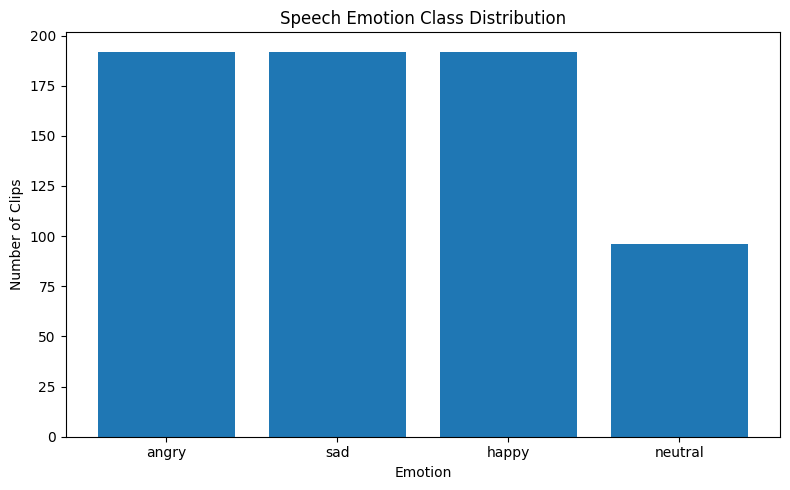

In [27]:
emotion_counts = df["emotion"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title("Speech Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Clips")

plt.tight_layout()

os.makedirs("/content/assets", exist_ok=True)

plt.savefig(
    "/content/assets/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Loading Audio Files

In [28]:
SAMPLE_RATE = 22050

sample_file = df.iloc[0]["file_path"]

audio, sr = librosa.load(
    sample_file,
    sr=SAMPLE_RATE
)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

Audio shape: (91231,)
Sample rate: 22050
Duration: 4.1374603174603175 seconds


# Visualization

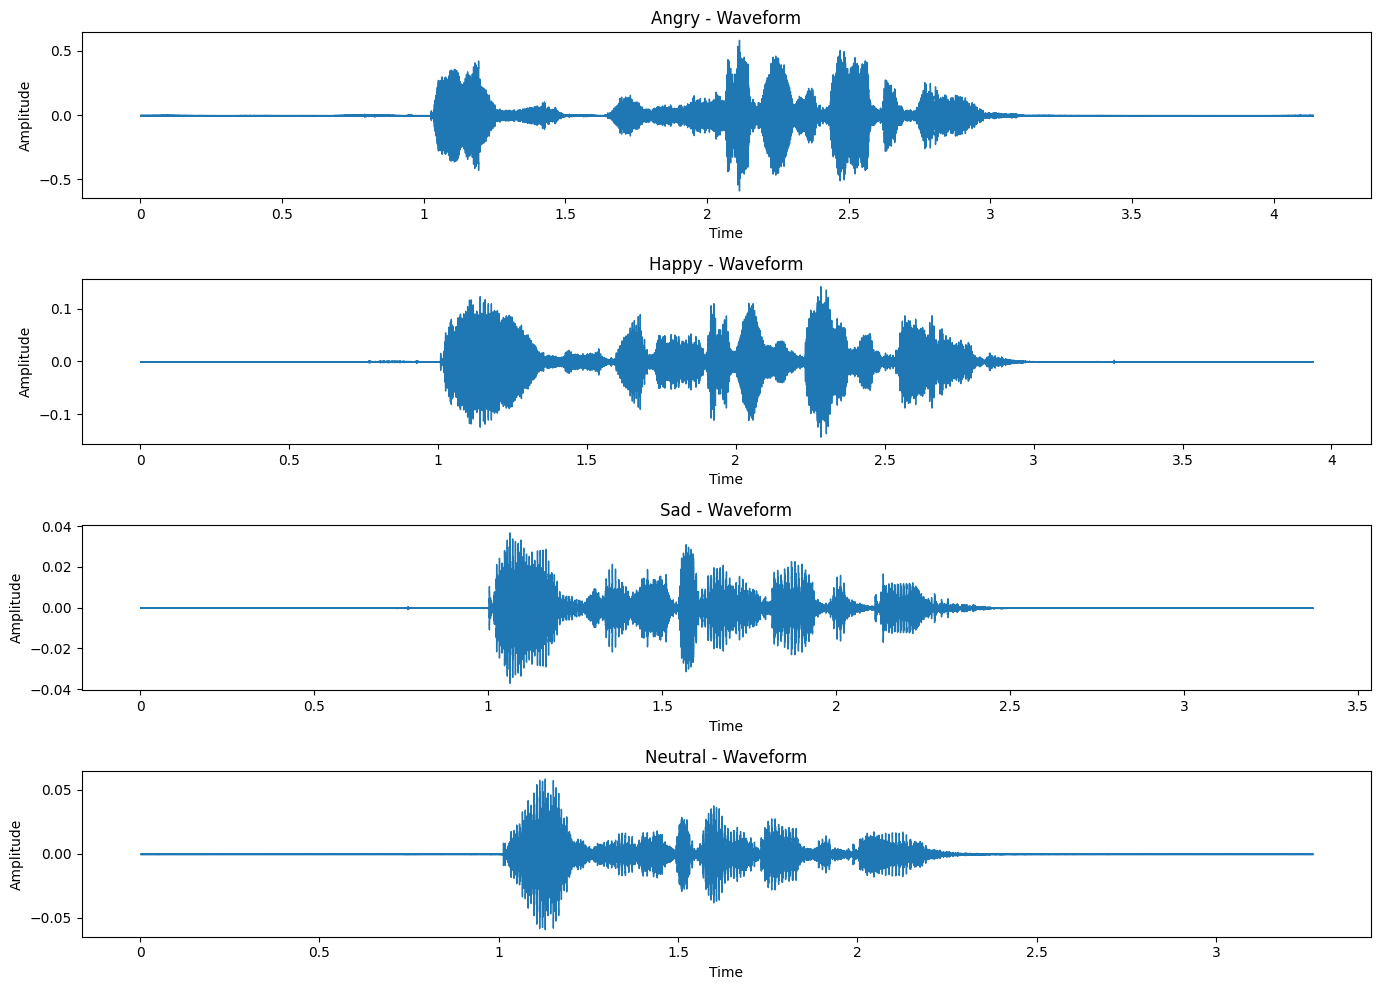

In [29]:
emotions = ["angry", "happy", "sad", "neutral"]

plt.figure(figsize=(14, 10))

for i, emotion in enumerate(emotions):

    sample = df[df["emotion"] == emotion].iloc[0]

    audio, sr = librosa.load(
        sample["file_path"],
        sr=SAMPLE_RATE
    )

    plt.subplot(4, 1, i + 1)

    librosa.display.waveshow(
        audio,
        sr=sr
    )

    plt.title(f"{emotion.capitalize()} - Waveform")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()

plt.savefig(
    "/content/assets/waveform_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

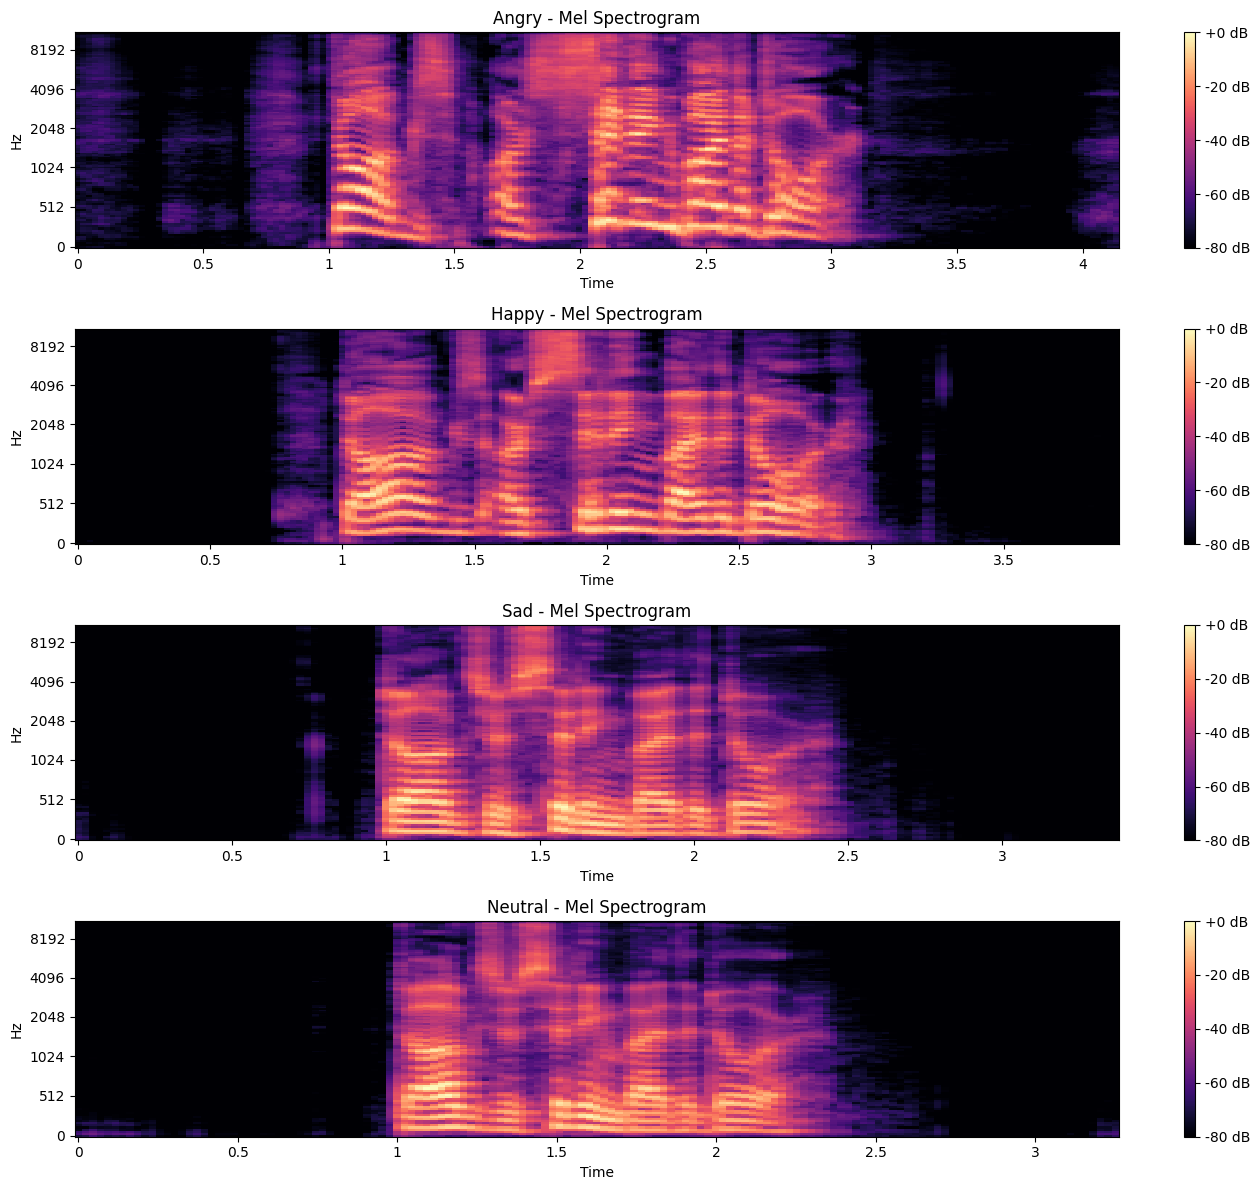

In [30]:
plt.figure(figsize=(14, 12))

for i, emotion in enumerate(emotions):

    sample = df[df["emotion"] == emotion].iloc[0]

    audio, sr = librosa.load(
        sample["file_path"],
        sr=SAMPLE_RATE
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.subplot(4, 1, i + 1)

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")

    plt.title(f"{emotion.capitalize()} - Mel Spectrogram")

plt.tight_layout()

plt.savefig(
    "/content/assets/mel_spectrogram_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Converting Audio into Numerical Vectors

In [33]:
def extract_mfcc_stats(
    file_path,
    sample_rate=22050,
    n_mfcc=40
):
    audio, sr = librosa.load(
        file_path,
        sr=sample_rate
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.min(mfcc, axis=1),
        np.max(mfcc, axis=1)
    ])

    return features

In [35]:
test_features = extract_mfcc_stats(
    df.iloc[0]["file_path"]
)

print("Feature shape:", test_features.shape)

print("\nFeatures:")
print(test_features)

Feature shape: (160,)

Features:
[-4.01701721e+02  2.99733047e+01 -1.57439852e+01  4.87853003e+00
 -6.71730614e+00 -3.91707158e+00 -1.13648500e+01 -9.56688404e+00
 -1.69579296e+01 -6.61014843e+00 -4.11258030e+00 -8.69593334e+00
 -3.18354535e+00 -4.62248611e+00 -4.60055113e+00  7.55844712e-01
 -1.00595741e+01 -1.72822165e+00 -3.38018060e+00 -4.48922873e+00
 -2.89923811e+00  1.61102161e-01 -2.37280369e+00  5.68444848e-01
  2.05684379e-01  1.61383092e+00 -1.73976019e-01  8.28834474e-01
 -1.29658401e+00  1.02796984e+00  7.76659667e-01  1.13080442e+00
 -1.11124933e+00  1.06512532e-02 -9.95753706e-01  2.96002579e+00
  1.70036244e+00  3.27391291e+00  4.55974460e-01  1.73352361e+00
  1.86902817e+02  5.47051125e+01  2.46390171e+01  1.69822350e+01
  2.27112026e+01  2.19873543e+01  1.37758846e+01  1.36987486e+01
  1.59161386e+01  1.04380236e+01  9.84640503e+00  8.76732922e+00
  7.10677528e+00  8.46940041e+00  1.11318569e+01  9.44005013e+00
  1.04196777e+01  7.02308702e+00  7.42545748e+00  7.37957

In [36]:
features = []
labels = []
actors = []

for _, row in df.iterrows():

    try:
        mfcc_features = extract_mfcc_stats(
            row["file_path"]
        )

        features.append(mfcc_features)
        labels.append(row["emotion"])
        actors.append(row["actor"])

    except Exception as e:
        print(
            f"Error processing {row['file_path']}: {e}"
        )

X = np.array(features)
y = np.array(labels)
actors = np.array(actors)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("actors shape:", actors.shape)

X shape: (672, 160)
y shape: (672,)
actors shape: (672,)


In [37]:
feature_df = pd.DataFrame(X)

feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,159
0,-401.701721,29.973305,-15.743985,4.878530,-6.717306,-3.917072,-11.364850,-9.566884,-16.957930,-6.610148,...,35.297451,25.402449,23.464142,22.236256,22.665596,26.525236,29.234858,39.639004,23.438850,35.622005
1,-711.786194,59.567207,0.710945,15.603700,6.023351,-0.162291,1.246117,-7.515767,-12.228474,-3.974104,...,3.731630,7.730674,9.088024,4.450390,4.158292,4.724525,7.399040,4.942789,3.448322,7.193413
2,-691.587891,58.024662,0.159465,13.624650,5.374113,1.162336,-2.083359,-5.382585,-10.332823,-3.662082,...,5.035260,7.278200,6.320383,7.192186,2.594035,5.619018,8.762008,4.240767,1.626808,8.412695
3,-605.888977,50.817348,-4.100936,13.333531,2.314354,-3.124966,-6.993569,-8.871110,-15.973222,-3.851796,...,3.654146,4.354603,5.111119,5.256434,9.009242,21.113079,18.606621,16.819237,18.398781,22.871555
4,-669.919495,62.426224,0.902358,16.833582,7.811779,-1.847560,-0.910654,-7.485836,-9.419272,-1.507419,...,7.927051,7.789203,6.239422,7.028470,5.394059,5.452876,4.267435,4.952484,4.741181,4.598325


# Spiltting Data For Training and Testing

In [38]:
train_mask = actors <= 18
test_mask = actors >= 19

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 504
Testing samples: 168

Training class distribution:
angry      144
sad        144
happy      144
neutral     72
Name: count, dtype: int64

Testing class distribution:
angry      48
happy      48
sad        48
neutral    24
Name: count, dtype: int64


In [39]:
print("Training class distribution:")

print(
    pd.Series(y_train).value_counts()
)

Training class distribution:
angry      144
sad        144
happy      144
neutral     72
Name: count, dtype: int64


# Training the Model "Random Forest Classifier"

In [40]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Model training completed.")

Model training completed.


In [41]:
y_pred = model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [42]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.6012
Accuracy: 60.12%


In [43]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Macro F1: 0.5404


# Classification Report

In [44]:
report = classification_report(
    y_test,
    y_pred,
    labels=emotions,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       angry       0.72      0.81      0.76        48
       happy       0.63      0.60      0.62        48
         sad       0.56      0.60      0.58        48
     neutral       0.25      0.17      0.20        24

    accuracy                           0.60       168
   macro avg       0.54      0.55      0.54       168
weighted avg       0.58      0.60      0.59       168



# Confusion Matrix

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=emotions
)

print(cm)

[[39  7  1  1]
 [11 29  7  1]
 [ 3  6 29 10]
 [ 1  4 15  4]]


## Saving the Model

In [51]:
SAMPLE_RATE = 22050
N_MFCC = 40

In [52]:
model_artifact = {
    "model": model,
    "labels": emotions,
    "sample_rate": SAMPLE_RATE,
    "n_mfcc": N_MFCC
}

model_path = "/content/speech_emotion_model.joblib"

joblib.dump(
    model_artifact,
    model_path
)

print(
    "Model saved:",
    model_path
)

Model saved: /content/speech_emotion_model.joblib


# Saving Evaluation Metrices

In [47]:
metrics = {
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "labels": emotions,
    "train_actors": list(range(1, 19)),
    "test_actors": list(range(19, 25))
}

with open(
    "/content/metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("Metrics saved.")

Metrics saved.


# Saving Confusion Metrices

In [48]:
np.save(
    "/content/confusion_matrix.npy",
    cm
)

print("Confusion matrix saved.")

Confusion matrix saved.


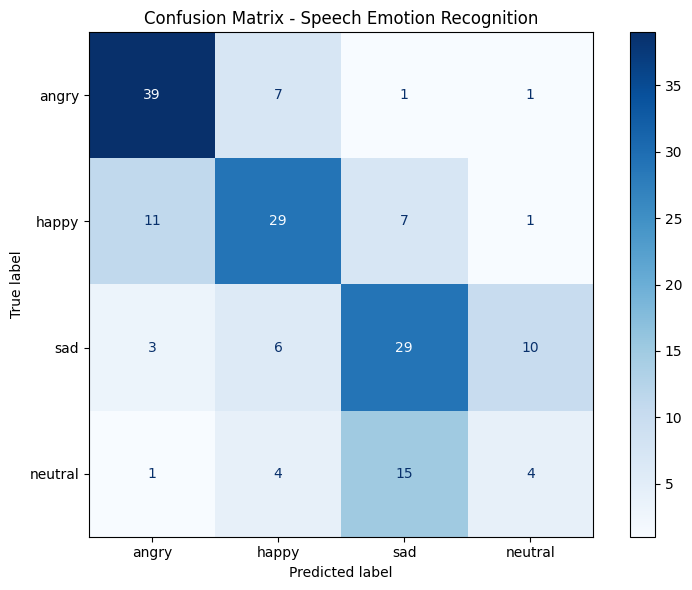

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)

plt.title("Confusion Matrix - Speech Emotion Recognition")
plt.tight_layout()

# Save the plot as an asset
os.makedirs("/content/assets", exist_ok=True)
plt.savefig("/content/assets/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Testing Saved Model

In [53]:
loaded_artifact = joblib.load(
    "/content/speech_emotion_model.joblib"
)

loaded_model = loaded_artifact["model"]

loaded_sample_rate = loaded_artifact["sample_rate"]
loaded_n_mfcc = loaded_artifact["n_mfcc"]

print("Sample rate:", loaded_sample_rate)
print("MFCC:", loaded_n_mfcc)
print("Classes:", loaded_model.classes_)

Sample rate: 22050
MFCC: 40
Classes: ['angry' 'happy' 'neutral' 'sad']


# Testing Saved Model Predictions

In [55]:
sample_path = df.iloc[0]["file_path"]

sample_features = extract_mfcc_stats(
    sample_path,
    sample_rate=loaded_sample_rate,
    n_mfcc=loaded_n_mfcc
)

sample_features = sample_features.reshape(
    1, -1
)

prediction = loaded_model.predict(
    sample_features
)

probabilities = loaded_model.predict_proba(
    sample_features
)

print("Predicted emotion:", prediction[0])

print("\nProbabilities:")

for emotion, probability in zip(
    loaded_model.classes_,
    probabilities[0]
):

    print(
        f"{emotion}: {probability:.4f}"
    )

Predicted emotion: angry

Probabilities:
angry: 0.8167
happy: 0.1467
neutral: 0.0067
sad: 0.0300


# eXTRAS

In [56]:
print(df.groupby(["actor", "emotion"]).size().unstack(fill_value=0))

emotion  angry  happy  neutral  sad
actor                              
1            8      8        4    8
2            8      8        4    8
3            8      8        4    8
4            8      8        4    8
5            8      8        4    8
6            8      8        4    8
7            8      8        4    8
8            8      8        4    8
9            8      8        4    8
10           8      8        4    8
11           8      8        4    8
12           8      8        4    8
13           8      8        4    8
14           8      8        4    8
15           8      8        4    8
16           8      8        4    8
17           8      8        4    8
18           8      8        4    8
19           8      8        4    8
20           8      8        4    8
21           8      8        4    8
22           8      8        4    8
23           8      8        4    8
24           8      8        4    8


In [57]:
print(df["emotion"].value_counts())

emotion
angry      192
sad        192
happy      192
neutral     96
Name: count, dtype: int64


In [58]:
print(
    pd.crosstab(
        df["actor"],
        df["emotion"]
    )
)

emotion  angry  happy  neutral  sad
actor                              
1            8      8        4    8
2            8      8        4    8
3            8      8        4    8
4            8      8        4    8
5            8      8        4    8
6            8      8        4    8
7            8      8        4    8
8            8      8        4    8
9            8      8        4    8
10           8      8        4    8
11           8      8        4    8
12           8      8        4    8
13           8      8        4    8
14           8      8        4    8
15           8      8        4    8
16           8      8        4    8
17           8      8        4    8
18           8      8        4    8
19           8      8        4    8
20           8      8        4    8
21           8      8        4    8
22           8      8        4    8
23           8      8        4    8
24           8      8        4    8


In [59]:
print("TRAIN ACTORS:")
print(sorted(df[df["actor"] <= 18]["actor"].unique()))

print("\nTEST ACTORS:")
print(sorted(df[df["actor"] >= 19]["actor"].unique()))

TRAIN ACTORS:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]

TEST ACTORS:
[np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [60]:
print(
    df[df["actor"] == 1][
        ["file_path", "emotion_code", "emotion"]
    ].to_string(index=False)
)

                                         file_path emotion_code emotion
/content/ravdess/Actor_01/03-01-05-02-02-01-01.wav           05   angry
/content/ravdess/Actor_01/03-01-04-01-02-02-01.wav           04     sad
/content/ravdess/Actor_01/03-01-01-01-02-01-01.wav           01 neutral
/content/ravdess/Actor_01/03-01-04-02-02-02-01.wav           04     sad
/content/ravdess/Actor_01/03-01-04-02-01-01-01.wav           04     sad
/content/ravdess/Actor_01/03-01-05-01-02-01-01.wav           05   angry
/content/ravdess/Actor_01/03-01-04-01-02-01-01.wav           04     sad
/content/ravdess/Actor_01/03-01-03-02-02-02-01.wav           03   happy
/content/ravdess/Actor_01/03-01-04-02-02-01-01.wav           04     sad
/content/ravdess/Actor_01/03-01-03-01-01-02-01.wav           03   happy
/content/ravdess/Actor_01/03-01-04-02-01-02-01.wav           04     sad
/content/ravdess/Actor_01/03-01-05-01-01-02-01.wav           05   angry
/content/ravdess/Actor_01/03-01-05-02-01-02-01.wav           05 

In [61]:
print(
    df[df["actor"] == 1]["file_path"].apply(
        lambda x: os.path.basename(x)
    ).tolist()
)

['03-01-05-02-02-01-01.wav', '03-01-04-01-02-02-01.wav', '03-01-01-01-02-01-01.wav', '03-01-04-02-02-02-01.wav', '03-01-04-02-01-01-01.wav', '03-01-05-01-02-01-01.wav', '03-01-04-01-02-01-01.wav', '03-01-03-02-02-02-01.wav', '03-01-04-02-02-01-01.wav', '03-01-03-01-01-02-01.wav', '03-01-04-02-01-02-01.wav', '03-01-05-01-01-02-01.wav', '03-01-05-02-01-02-01.wav', '03-01-03-01-02-02-01.wav', '03-01-03-02-01-01-01.wav', '03-01-03-02-01-02-01.wav', '03-01-05-01-02-02-01.wav', '03-01-04-01-01-02-01.wav', '03-01-03-02-02-01-01.wav', '03-01-03-01-01-01-01.wav', '03-01-01-01-01-02-01.wav', '03-01-01-01-02-02-01.wav', '03-01-05-02-02-02-01.wav', '03-01-04-01-01-01-01.wav', '03-01-03-01-02-01-01.wav', '03-01-05-01-01-01-01.wav', '03-01-05-02-01-01-01.wav', '03-01-01-01-01-01-01.wav']


In [62]:
# Cell 32
import joblib
import numpy as np

# Load the saved model
model_artifact = joblib.load(
    "/content/speech_emotion_model.joblib"
)

loaded_model = model_artifact["model"]

print("Model loaded successfully!")

print("Labels:", model_artifact["labels"])
print("Sample rate:", model_artifact["sample_rate"])
print("MFCC:", model_artifact["n_mfcc"])

Model loaded successfully!
Labels: ['angry', 'happy', 'sad', 'neutral']
Sample rate: 22050
MFCC: 40


In [63]:
# Test one sample

sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

print("Predicted emotion:", prediction[0])

Predicted emotion: angry


In [64]:
print("Number of features:", X_test.shape[1])

Number of features: 160


In [65]:
# Cell 33
from google.colab import files

files.download(
    "/content/speech_emotion_model.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>